In [196]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("dataset.csv - Sheet1.csv")

# Display first 5 rows
print(df.head())

# Display shape
print("\nDataset shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())


   EC (mg L-1)  AV (V)  SSA (m2 g-1)  C (F g-1)  SAC (mg g-1)
0          100     1.4          13.3      129.0          23.6
1          300     1.4          13.3      129.0          39.6
2          500     1.4          13.3      129.0          49.2
3          700     1.4          13.3      129.0          52.6
4         1000     1.4          13.3      129.0          53.7

Dataset shape: (510, 5)

Columns:
['EC (mg L-1)', 'AV (V)', 'SSA (m2 g-1)', 'C (F g-1)', 'SAC (mg g-1)']


In [197]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset information:")
df.info()

Missing values:
EC (mg L-1)     0
AV (V)          0
SSA (m2 g-1)    0
C (F g-1)       0
SAC (mg g-1)    0
dtype: int64

Duplicate rows: 0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EC (mg L-1)   510 non-null    int64  
 1   AV (V)        510 non-null    float64
 2   SSA (m2 g-1)  510 non-null    float64
 3   C (F g-1)     510 non-null    float64
 4   SAC (mg g-1)  510 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 20.1 KB


In [198]:
X = df[['C (F g-1)',
        'SSA (m2 g-1)',
        'EC (mg L-1)',
        'AV (V)']]

y = df['SAC (mg g-1)']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (510, 4)
y shape: (510,)

Features:
['C (F g-1)', 'SSA (m2 g-1)', 'EC (mg L-1)', 'AV (V)']

Target:
SAC (mg g-1)


In [199]:
!pip install -q xgboost lightgbm catboost ngboost

import numpy as np
import pandas as pd

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor
)

from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    KFold,
    GridSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.base import clone

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from ngboost import NGBRegressor

import matplotlib.pyplot as plt

In [200]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Number of outer CV folds:", kf.n_splits)
print("Total samples:", len(y))

Number of outer CV folds: 5
Total samples: 510


In [201]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [202]:
gbdt = GradientBoostingRegressor(
    random_state=42
)

gbdt_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4]
}

In [203]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 9],
    'max_features': ['sqrt', 1.0]
}

In [204]:
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(
        kernel='rbf'
    ))
])

svm_param_grid = {
    'svr__C': [1, 3, 10],
    'svr__gamma': ['scale', 0.1],
    'svr__epsilon': [0.1]
}

In [205]:
ann = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    ))
])

ann_param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'mlp__learning_rate_init': [0.001, 0.005]
}

In [206]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1
)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

In [207]:
lgbm = LGBMRegressor(
    random_state=42,
    verbosity=-1,
    n_jobs=1
)

lgbm_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'num_leaves': [15]
}

In [208]:
catboost = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=False,
    thread_count=1
)

catboost_param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 5],
    'l2_leaf_reg': [3]
}

In [209]:
ngboost = NGBRegressor(
    random_state=42,
    verbose=False
)

ngboost_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'minibatch_frac': [0.8]
}

In [210]:
models = {
    'GBDT': gbdt,
    'Random Forest': rf,
    'SVM': svm,
    'ANN': ann,
    'XGBoost': xgb,
    'LightGBM': lgbm,
    'CatBoost': catboost,
    'NGBoost': ngboost
}

param_grids = {
    'GBDT': gbdt_param_grid,
    'Random Forest': rf_param_grid,
    'SVM': svm_param_grid,
    'ANN': ann_param_grid,
    'XGBoost': xgb_param_grid,
    'LightGBM': lgbm_param_grid,
    'CatBoost': catboost_param_grid,
    'NGBoost': ngboost_param_grid
}

print("Models and compact GridSearchCV parameter spaces created.")

Models and compact GridSearchCV parameter spaces created.


In [211]:
oof_predictions = {
    model_name: np.zeros(len(y))
    for model_name in models
}

fold_results = []
best_params_by_fold = []

print("OOF prediction arrays created.")
print("Number of observations:", len(y))
print("Number of models:", len(models))
print("Number of outer folds:", kf.n_splits)

OOF prediction arrays created.
Number of observations: 510
Number of models: 8
Number of outer folds: 5


In [212]:
inner_kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Inner Grid Search CV folds:", inner_kf.n_splits)
print("GridSearchCV will optimize hyperparameters independently")
print("inside every outer training fold.")

Inner Grid Search CV folds: 3
GridSearchCV will optimize hyperparameters independently
inside every outer training fold.


In [213]:
for model_name, model in models.items():

    print("\n" + "=" * 70)
    print(f"MODEL: {model_name}")
    print("=" * 70)

    oof_pred = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

        print(f"\n----- OUTER FOLD {fold}/5 -----")

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        grid_search = GridSearchCV(
            estimator=clone(model),
            param_grid=param_grids[model_name],
            scoring='neg_root_mean_squared_error',
            cv=inner_kf,
            n_jobs=-1,
            refit=True,
            verbose=0
        )

        print("Running compact GridSearchCV...")

        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_inner_rmse = -grid_search.best_score_

        print("Best parameters:")
        print(best_params)
        print(f"Best inner CV RMSE: {best_inner_rmse:.4f}")

        predictions = best_model.predict(X_val)
        oof_pred[val_idx] = predictions

        fold_mae = mean_absolute_error(y_val, predictions)
        fold_mse = mean_squared_error(y_val, predictions)
        fold_rmse = np.sqrt(fold_mse)
        fold_r2 = r2_score(y_val, predictions)

        fold_results.append({
            'Model': model_name,
            'Fold': fold,
            'MAE': fold_mae,
            'MSE': fold_mse,
            'RMSE': fold_rmse,
            'R2': fold_r2,
            'Best Inner CV RMSE': best_inner_rmse
        })

        best_params_by_fold.append({
            'Model': model_name,
            'Outer Fold': fold,
            **best_params
        })

        print(f"Outer Fold {fold} MAE  : {fold_mae:.4f}")
        print(f"Outer Fold {fold} MSE  : {fold_mse:.4f}")
        print(f"Outer Fold {fold} RMSE : {fold_rmse:.4f}")
        print(f"Outer Fold {fold} R²   : {fold_r2:.4f}")

    oof_predictions[model_name] = oof_pred

    mae, mse, rmse, r2 = calculate_metrics(y, oof_pred)

    print("\n" + "-" * 60)
    print(f"{model_name} POOLED NESTED OOF RESULTS")
    print("-" * 60)
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

print("\n" + "=" * 70)
print("NESTED 5-FOLD COMPACT GRID SEARCH OOF EVALUATION COMPLETE")
print("=" * 70)


MODEL: GBDT

----- OUTER FOLD 1/5 -----
Running compact GridSearchCV...
Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best inner CV RMSE: 9.5571
Outer Fold 1 MAE  : 6.0635
Outer Fold 1 MSE  : 72.9397
Outer Fold 1 RMSE : 8.5405
Outer Fold 1 R²   : 0.8268

----- OUTER FOLD 2/5 -----
Running compact GridSearchCV...
Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best inner CV RMSE: 9.8417
Outer Fold 2 MAE  : 7.2594
Outer Fold 2 MSE  : 130.9104
Outer Fold 2 RMSE : 11.4416
Outer Fold 2 R²   : 0.7668

----- OUTER FOLD 3/5 -----
Running compact GridSearchCV...
Best parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
Best inner CV RMSE: 10.2152
Outer Fold 3 MAE  : 4.9390
Outer Fold 3 MSE  : 67.3295
Outer Fold 3 RMSE : 8.2055
Outer Fold 3 R²   : 0.8317

----- OUTER FOLD 4/5 -----
Running compact GridSearchCV...
Best parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
Best inner CV RMSE: 11.5286


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Best parameters:
{'mlp__hidden_layer_sizes': (50, 25), 'mlp__learning_rate_init': 0.005}
Best inner CV RMSE: 16.5010
Outer Fold 3 MAE  : 7.7052
Outer Fold 3 MSE  : 118.5247
Outer Fold 3 RMSE : 10.8869
Outer Fold 3 R²   : 0.7037

----- OUTER FOLD 4/5 -----
Running compact GridSearchCV...
Best parameters:
{'mlp__hidden_layer_sizes': (50, 25), 'mlp__learning_rate_init': 0.005}
Best inner CV RMSE: 16.9255
Outer Fold 4 MAE  : 7.9359
Outer Fold 4 MSE  : 115.6901
Outer Fold 4 RMSE : 10.7559
Outer Fold 4 R²   : 0.7038

----- OUTER FOLD 5/5 -----
Running compact GridSearchCV...


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Best parameters:
{'mlp__hidden_layer_sizes': (50, 25), 'mlp__learning_rate_init': 0.005}
Best inner CV RMSE: 17.9939
Outer Fold 5 MAE  : 9.2023
Outer Fold 5 MSE  : 139.8669
Outer Fold 5 RMSE : 11.8265
Outer Fold 5 R²   : 0.7395

------------------------------------------------------------
ANN POOLED NESTED OOF RESULTS
------------------------------------------------------------
MAE  : 9.2566
MSE  : 159.0663
RMSE : 12.6121
R²   : 0.6597

MODEL: XGBoost

----- OUTER FOLD 1/5 -----
Running compact GridSearchCV...
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best inner CV RMSE: 9.7257
Outer Fold 1 MAE  : 5.7712
Outer Fold 1 MSE  : 64.6747
Outer Fold 1 RMSE : 8.0421
Outer Fold 1 R²   : 0.8464

----- OUTER FOLD 2/5 -----
Running compact GridSearchCV...
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best inner CV RMSE: 9.4571
Outer Fold 2 MAE  : 6

In [214]:
best_params_df = pd.DataFrame(best_params_by_fold)

for model_name in best_params_df['Model'].unique():
    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    display(
        best_params_df[
            best_params_df['Model'] == model_name
        ].dropna(axis=1, how='all').reset_index(drop=True)
    )

best_params_df.to_csv(
    'SAC_510_8Model_Best_Parameters_By_Outer_Fold.csv',
    index=False
)


GBDT


,Model,Outer Fold,learning_rate,max_depth,n_estimators
0,GBDT,1,0.1,3.0,300.0
1,GBDT,2,0.1,3.0,300.0
2,GBDT,3,0.1,4.0,300.0
3,GBDT,4,0.1,4.0,300.0
4,GBDT,5,0.1,4.0,300.0



Random Forest


,Model,Outer Fold,n_estimators,max_features
0,Random Forest,1,200.0,1.0
1,Random Forest,2,400.0,1.0
2,Random Forest,3,200.0,1.0
3,Random Forest,4,200.0,sqrt
4,Random Forest,5,400.0,1.0



SVM


...

,Model,Outer Fold,learning_rate,max_depth,n_estimators,num_leaves
0,LightGBM,1,0.1,5.0,200.0,15.0
1,LightGBM,2,0.1,5.0,200.0,15.0
2,LightGBM,3,0.1,5.0,200.0,15.0
3,LightGBM,4,0.1,5.0,200.0,15.0
4,LightGBM,5,0.1,5.0,200.0,15.0



CatBoost


,Model,Outer Fold,learning_rate,depth,iterations,l2_leaf_reg
0,CatBoost,1,0.1,5.0,200.0,3.0
1,CatBoost,2,0.1,5.0,200.0,3.0
2,CatBoost,3,0.1,5.0,200.0,3.0
3,CatBoost,4,0.1,4.0,200.0,3.0
4,CatBoost,5,0.1,5.0,200.0,3.0



NGBoost


,Model,Outer Fold,learning_rate,n_estimators,minibatch_frac
0,NGBoost,1,0.10,200.0,0.8
1,NGBoost,2,0.10,200.0,0.8
2,NGBoost,3,0.10,200.0,0.8
3,NGBoost,4,0.05,200.0,0.8
4,NGBoost,5,0.10,200.0,0.8


In [215]:
results = []

for model_name, predictions in oof_predictions.items():

    mae, mse, rmse, r2 = calculate_metrics(
        y,
        predictions
    )

    results.append({
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='RMSE',
    ascending=True
).reset_index(drop=True)

display(
    results_df.round(4)
)

,Model,MAE,MSE,RMSE,R2
0,XGBoost,5.2252,63.1548,7.9470,0.8649
1,GBDT,5.4952,69.6741,8.3471,0.8509
2,NGBoost,6.0068,72.5690,8.5187,0.8448
3,CatBoost,6.4314,81.8778,9.0486,0.8248
4,LightGBM,7.0294,97.1449,9.8562,0.7922
5,Random Forest,6.9188,100.3967,10.0198,0.7852
6,ANN,9.2566,159.0663,12.6121,0.6597
7,SVM,11.3066,307.3888,17.5325,0.3424


In [216]:
results_display = results_df.copy()

for column in ['MAE', 'MSE', 'RMSE', 'R2']:
    results_display[column] = results_display[column].round(4)

display(results_display)

,Model,MAE,MSE,RMSE,R2
0,XGBoost,5.2252,63.1548,7.9470,0.8649
1,GBDT,5.4952,69.6741,8.3471,0.8509
2,NGBoost,6.0068,72.5690,8.5187,0.8448
3,CatBoost,6.4314,81.8778,9.0486,0.8248
4,LightGBM,7.0294,97.1449,9.8562,0.7922
5,Random Forest,6.9188,100.3967,10.0198,0.7852
6,ANN,9.2566,159.0663,12.6121,0.6597
7,SVM,11.3066,307.3888,17.5325,0.3424


In [217]:
best_model = results_df.iloc[0]

print("BEST MODEL")
print("=" * 40)

print("Model :", best_model['Model'])
print("MAE   :", round(best_model['MAE'], 4))
print("MSE   :", round(best_model['MSE'], 4))
print("RMSE  :", round(best_model['RMSE'], 4))
print("R²    :", round(best_model['R2'], 4))

BEST MODEL
Model : XGBoost
MAE   : 5.2252
MSE   : 63.1548
RMSE  : 7.947
R²    : 0.8649


In [218]:
oof_df = df.copy()

for model_name, predictions in oof_predictions.items():
    oof_df[model_name + ' OOF Prediction'] = predictions

display(oof_df.head())

,EC (mg L-1),AV (V),SSA (m2 g-1),C (F g-1),SAC (mg g-1),GBDT OOF Prediction,Random Forest OOF Prediction,SVM OOF Prediction,ANN OOF Prediction,XGBoost OOF Prediction,LightGBM OOF Prediction,CatBoost OOF Prediction,NGBoost OOF Prediction
0,100,1.4,13.3,129.0,23.6,33.570511,26.84450,25.432467,19.076497,30.859945,33.433711,30.928923,31.759135
1,300,1.4,13.3,129.0,39.6,34.727167,31.54075,26.545378,25.834770,35.318047,35.176083,32.030433,31.264475
2,500,1.4,13.3,129.0,49.2,39.174165,36.70200,29.798107,35.967696,41.782551,39.286571,41.300942,38.618316
3,700,1.4,13.3,129.0,52.6,44.180051,45.03025,31.047441,35.025651,47.117878,48.112284,41.666038,45.542881
4,1000,1.4,13.3,129.0,53.7,60.274290,53.73150,33.523240,46.321609,63.188396,57.090475,58.096890,56.238603


In [219]:
oof_df.to_csv(
    'SAC_510_8Model_5Fold_OOF_Predictions.csv',
    index=False
)

print("OOF predictions saved successfully.")

OOF predictions saved successfully.


In [220]:
results_df.to_csv(
    'SAC_510_8Model_OOF_Metrics.csv',
    index=False
)

print("Model metrics saved successfully.")

Model metrics saved successfully.


In [221]:
error_df = pd.DataFrame()

for model_name, predictions in oof_predictions.items():

    error_df[model_name] = np.abs(
        y.values - predictions
    )

display(error_df.head())

,GBDT,Random Forest,SVM,ANN,XGBoost,LightGBM,CatBoost,NGBoost
0,9.970511,3.24450,1.832467,4.523503,7.259945,9.833711,7.328923,8.159135
1,4.872833,8.05925,13.054622,13.765230,4.281953,4.423917,7.569567,8.335525
2,10.025835,12.49800,19.401893,13.232304,7.417449,9.913429,7.899058,10.581684
3,8.419949,7.56975,21.552559,17.574349,5.482122,4.487716,10.933962,7.057119
4,6.574290,0.03150,20.176760,7.378391,9.488396,3.390475,4.396890,2.538603


In [222]:
row_winners = error_df.idxmin(axis=1)

win_counts = row_winners.value_counts()

win_percentages = (
    win_counts / len(y) * 100
)

wins_df = pd.DataFrame({
    'Model': win_counts.index,
    'Wins': win_counts.values,
    'Win Percentage': win_percentages.values
})

wins_df = wins_df.sort_values(
    by='Wins',
    ascending=False
).reset_index(drop=True)

wins_df['Win Percentage'] = wins_df[
    'Win Percentage'
].round(2)

display(wins_df)

,Model,Wins,Win Percentage
0,XGBoost,110,21.57
1,GBDT,89,17.45
2,LightGBM,61,11.96
3,SVM,61,11.96
4,Random Forest,52,10.20
5,ANN,50,9.80
6,CatBoost,48,9.41
7,NGBoost,39,7.65


In [223]:
wins_df.to_csv(
    'SAC_510_8Model_OOF_Win_Statistics.csv',
    index=False
)

print("Win statistics saved successfully.")

Win statistics saved successfully.


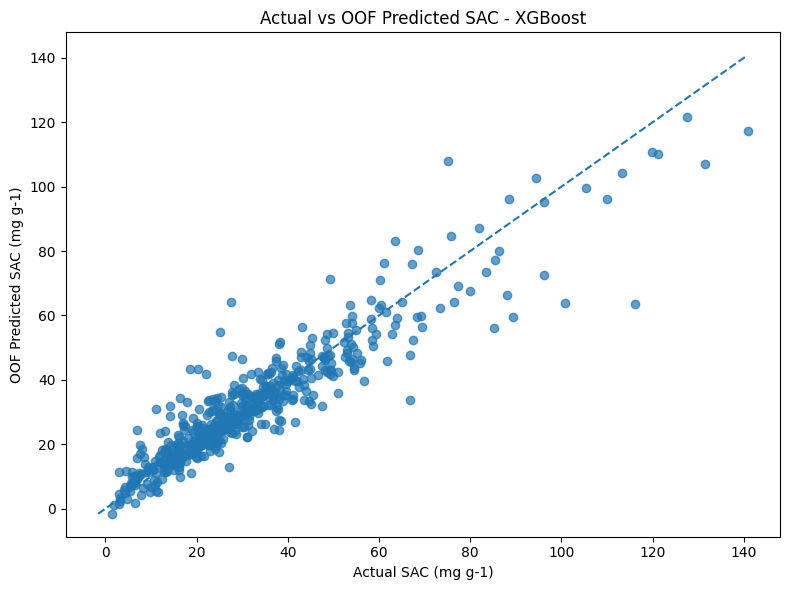

In [224]:
import matplotlib.pyplot as plt

best_model_name = results_df.iloc[0]['Model']

best_predictions = oof_predictions[best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(
    y,
    best_predictions,
    alpha=0.7
)

minimum = min(
    y.min(),
    best_predictions.min()
)

maximum = max(
    y.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--'
)

plt.xlabel('Actual SAC (mg g-1)')
plt.ylabel('OOF Predicted SAC (mg g-1)')

plt.title(
    f'Actual vs OOF Predicted SAC - {best_model_name}'
)

plt.tight_layout()
plt.show()

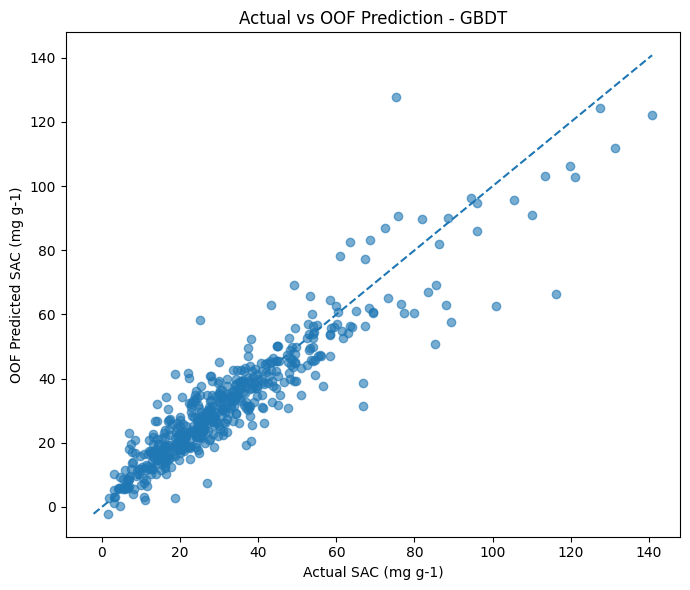

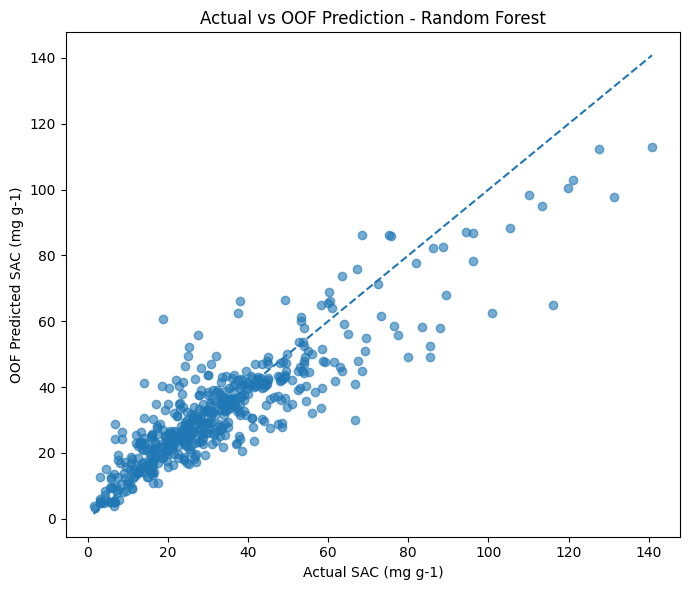

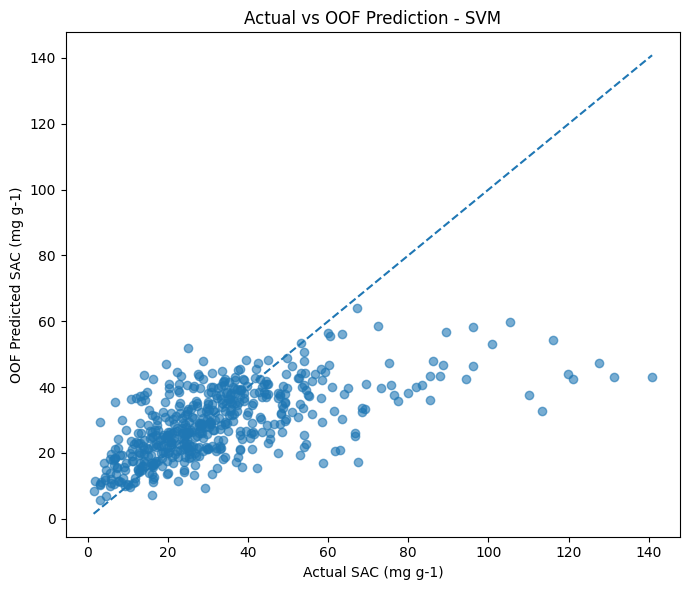

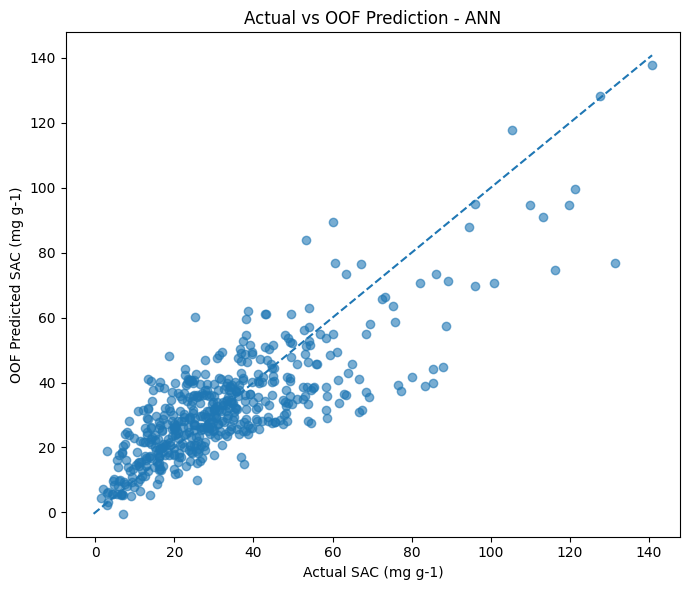

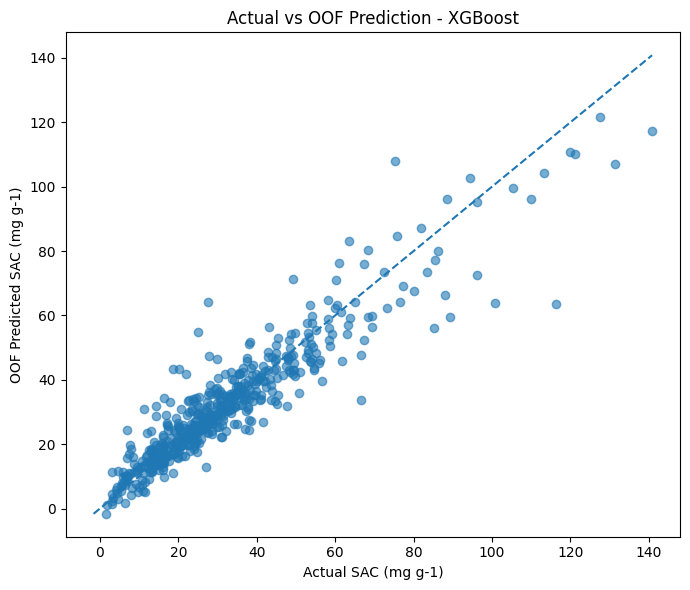

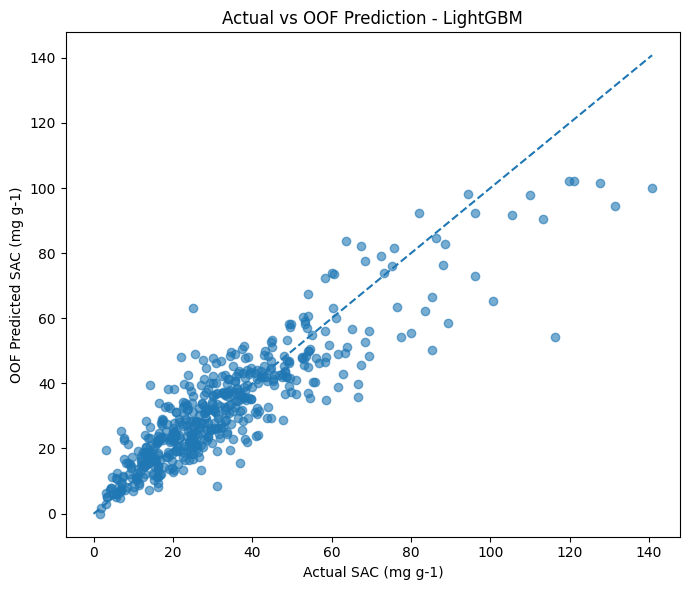

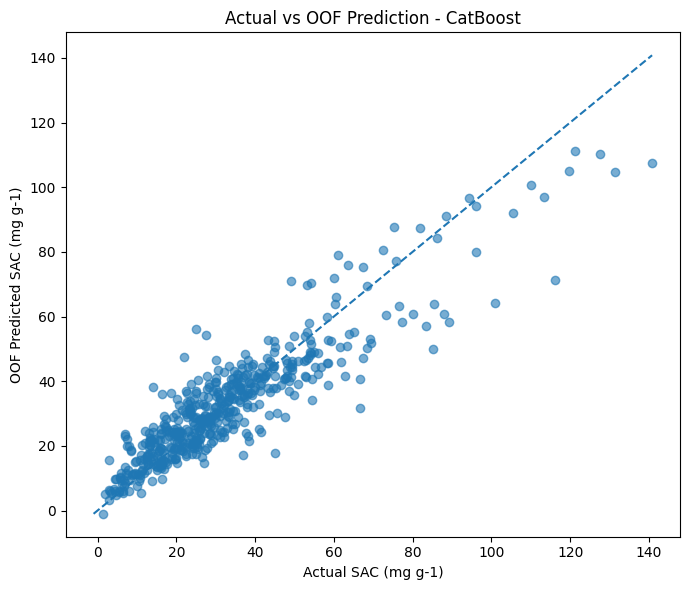

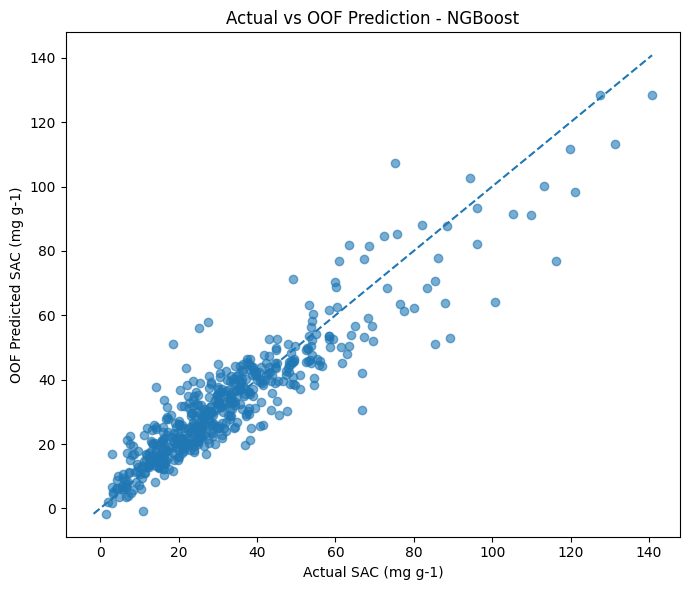

In [225]:
for model_name, predictions in oof_predictions.items():

    plt.figure(figsize=(7, 6))

    plt.scatter(
        y,
        predictions,
        alpha=0.6
    )

    minimum = min(
        y.min(),
        predictions.min()
    )

    maximum = max(
        y.max(),
        predictions.max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle='--'
    )

    plt.xlabel('Actual SAC (mg g-1)')
    plt.ylabel('OOF Predicted SAC (mg g-1)')

    plt.title(
        f'Actual vs OOF Prediction - {model_name}'
    )

    plt.tight_layout()
    plt.show()

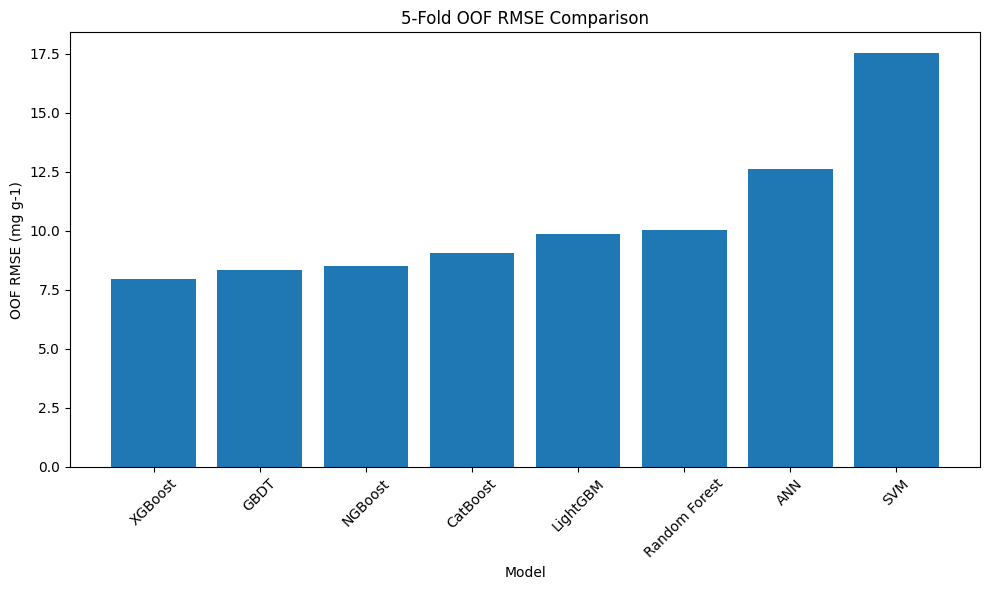

In [226]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.xlabel('Model')
plt.ylabel('OOF RMSE (mg g-1)')
plt.title('5-Fold OOF RMSE Comparison')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

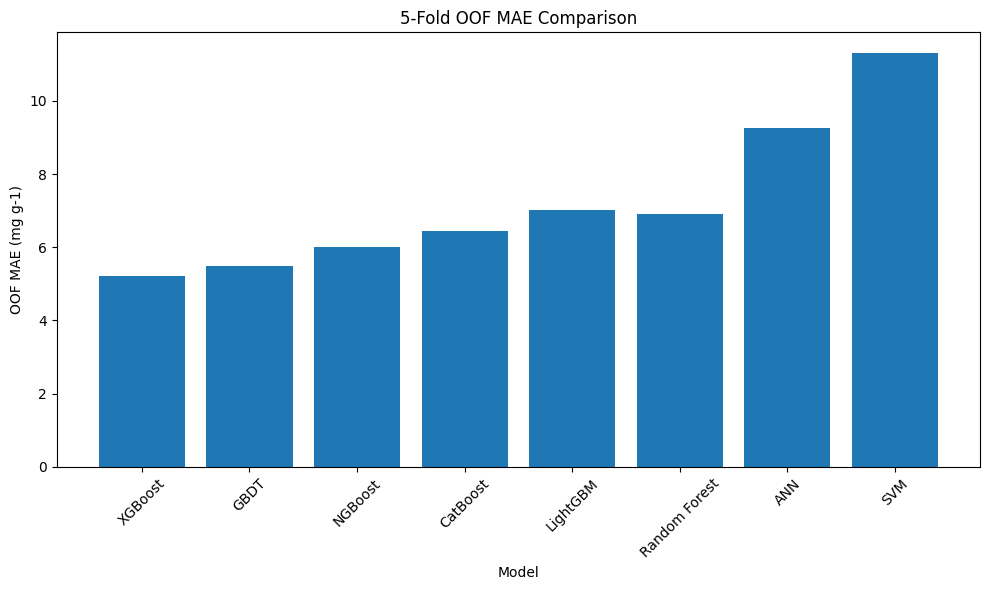

In [227]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['MAE']
)

plt.xlabel('Model')
plt.ylabel('OOF MAE (mg g-1)')
plt.title('5-Fold OOF MAE Comparison')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

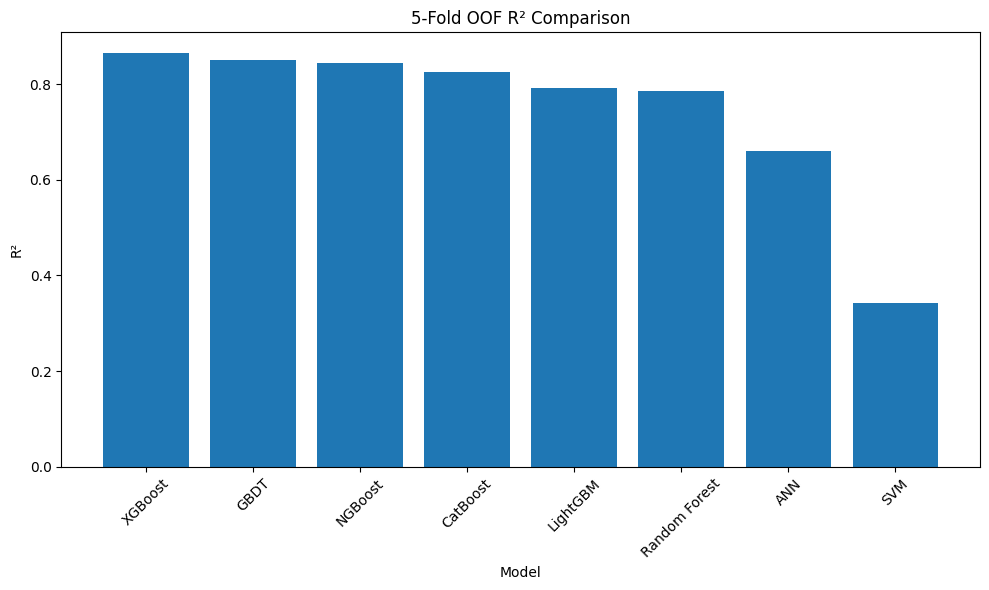

In [228]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['R2']
)

plt.xlabel('Model')
plt.ylabel('R²')
plt.title('5-Fold OOF R² Comparison')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [229]:
# Compare the best-performing model with the reference GBDT model

best_model_name = results_df.iloc[0]['Model']
best_rmse = results_df.iloc[0]['RMSE']

gbdt_rmse = results_df[
    results_df['Model'] == 'GBDT'
]['RMSE'].values[0]

if best_model_name != 'GBDT':

    improvement = (
        (gbdt_rmse - best_rmse)
        / gbdt_rmse
    ) * 100

    print(
        f"{best_model_name} reduces OOF RMSE by "
        f"{improvement:.2f}% compared with GBDT."
    )

else:

    print(
        "GBDT is the best-performing model "
        "based on OOF RMSE."
    )

XGBoost reduces OOF RMSE by 4.79% compared with GBDT.


In [230]:
final_summary = results_df.copy()

final_summary['Rank'] = range(
    1,
    len(final_summary) + 1
)

final_summary = final_summary[
    ['Rank', 'Model', 'MAE', 'MSE', 'RMSE', 'R2']
]

final_summary = final_summary.round(4)

display(final_summary)

,Rank,Model,MAE,MSE,RMSE,R2
0,1,XGBoost,5.2252,63.1548,7.9470,0.8649
1,2,GBDT,5.4952,69.6741,8.3471,0.8509
2,3,NGBoost,6.0068,72.5690,8.5187,0.8448
3,4,CatBoost,6.4314,81.8778,9.0486,0.8248
4,5,LightGBM,7.0294,97.1449,9.8562,0.7922
5,6,Random Forest,6.9188,100.3967,10.0198,0.7852
6,7,ANN,9.2566,159.0663,12.6121,0.6597
7,8,SVM,11.3066,307.3888,17.5325,0.3424


In [231]:
final_summary.to_csv(
    'SAC_Final_8Model_OOF_Comparison.csv',
    index=False
)

print("Final OOF comparison saved successfully.")

Final OOF comparison saved successfully.


In [232]:
import shap
import numpy as np
import pandas as pd

In [239]:
final_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1
)

final_xgb.fit(X, y)

print("Final XGBoost model trained successfully!")

Final XGBoost model trained successfully!


In [240]:
explainer_xgb = shap.TreeExplainer(final_xgb)

shap_values_xgb = explainer_xgb.shap_values(X)

print("SHAP values calculated successfully!")
print("Shape:", shap_values_xgb.shape)

SHAP values calculated successfully!
Shape: (510, 4)


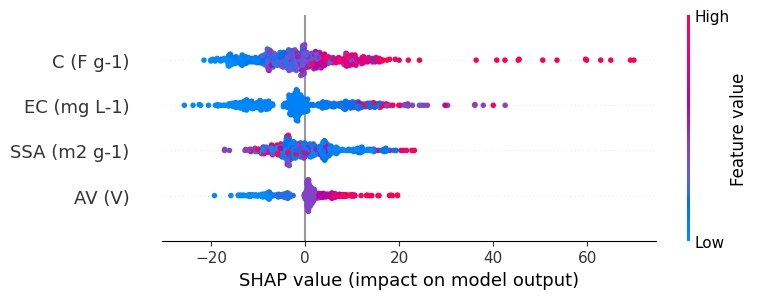

In [241]:
shap.summary_plot(
    shap_values_xgb,
    X,
    feature_names=X.columns
)

In [242]:
xgb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP': np.abs(shap_values_xgb).mean(axis=0)
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    'Mean Absolute SHAP',
    ascending=False
).reset_index(drop=True)

display(
    xgb_feature_importance.style.format({
        'Mean Absolute SHAP': '{:.3f}'
    })
)

,Feature,Mean Absolute SHAP
0,C (F g-1),8.183
1,EC (mg L-1),8.046
2,SSA (m2 g-1),5.177
3,AV (V),4.285


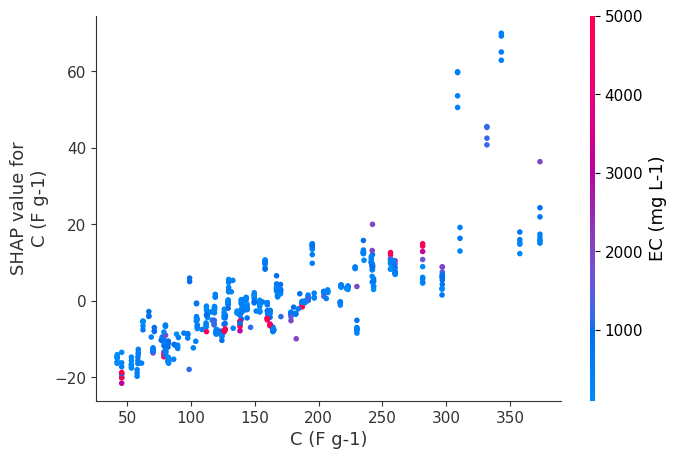

In [243]:
shap.dependence_plot(
    'C (F g-1)',
    shap_values_xgb,
    X
)

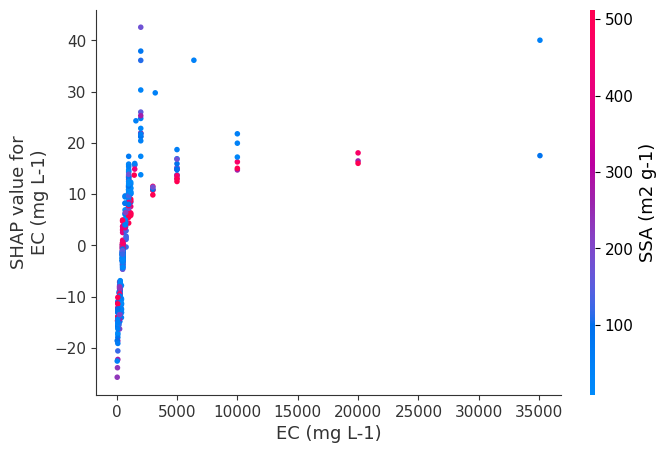

In [244]:
shap.dependence_plot(
    'EC (mg L-1)',
    shap_values_xgb,
    X
)